# AIDL A02: Neural Networks and Deep Learning PROJECT

## Student: Zelios Andreas mscaids-0142

## Custom CNN networks

In [13]:
import matplotlib.pyplot as plt
from tensorflow.keras import utils
from sklearn.model_selection import train_test_split
import os
import cv2
import numpy as np
%matplotlib inline
from google.colab import drive

In [14]:
# load data
drive.mount('/content/drive')

def load_data(dataset_dir):
    images = []
    labels = []
    size = 32,32
    index = -1
    for folder in sorted(os.listdir(dataset_dir)):
        index +=1
        for image in os.listdir(dataset_dir + "/" + folder):
            temp_img = cv2.imread(dataset_dir + '/' + folder + '/' + image)
            temp_img = cv2.resize(temp_img, size)
            images.append(temp_img)
            labels.append(index)

    images = np.array(images)
    images = images.astype('float32')/255.0
    labels = utils.to_categorical(labels)
    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size = 0.3, random_state = 1)

    print('Loaded', len(x_train),'images for training,','Train data shape =', x_train.shape)
    print('Loaded', len(x_test),'images for testing','Test data shape =', x_test.shape)
    return x_train, x_test, y_train, y_test

dataset_dir = '/content/drive/MyDrive/AIDL02/PROJECT/DATA'

# initial test and training
x_train, x_test, y_train, y_test = load_data(dataset_dir)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 47 images for training, Train data shape = (47, 32, 32, 3)
Loaded 21 images for testing Test data shape = (21, 32, 32, 3)


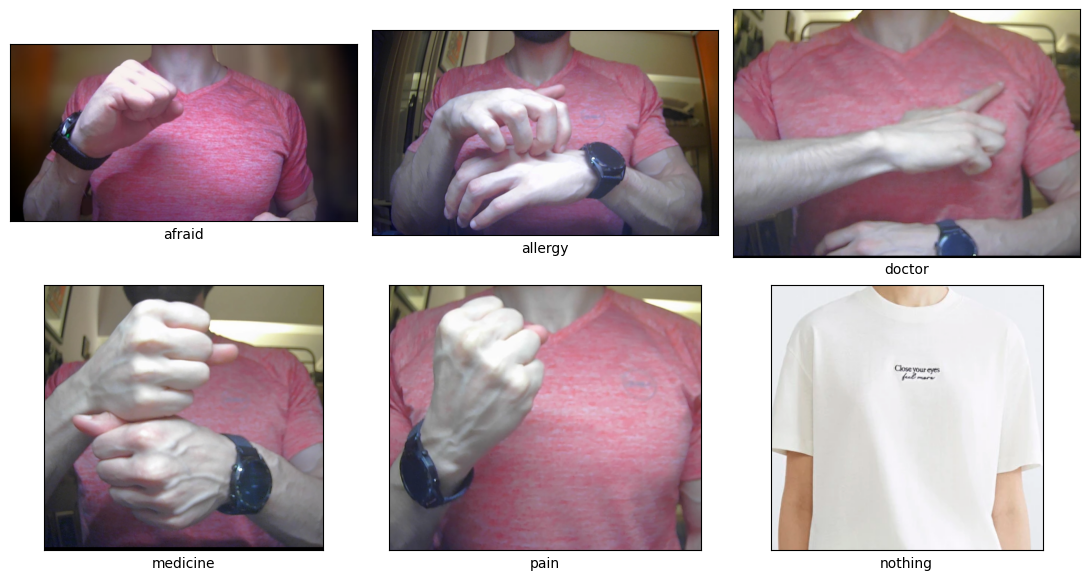

In [15]:
classes = ['afraid', 'allergy', 'doctor', 'medicine', 'pain', 'nothing']
plt.figure(figsize=(11, 6))

for i in range(0, 6):
    plt.subplot(2, 3, i+1)
    plt.xticks([])
    plt.yticks([])

    folder_path = dataset_dir + "/" + classes[i]
    first_image_name = sorted(os.listdir(folder_path))[0]
    path = folder_path + "/" + first_image_name

    img = plt.imread(path)
    plt.imshow(img)
    plt.xlabel(classes[i])

plt.tight_layout()
plt.show()

In [17]:
# we now split the training to validation/testing
x_train_n, x_val, y_train_n, y_val = train_test_split(x_train, y_train, test_size = 0.3, shuffle=True, random_state = 1)



### Network 1

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

seed = 2
tf.random.set_seed(seed)
np.random.seed(seed)

model = Sequential()

# first flatten to input the images
# 32x32 x 3 channels, so 3072 features each image
model.add(Flatten())

model.add(Dense(200, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(140, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(100, activation="relu"))
model.add(Dropout(0.2))

model.add(Dense(80, activation="relu"))
model.add(Dropout(0.2))

# we have multiple classes, so sigmoid cannot be used
model.add(Dense(len(classes), activation="softmax"))

batch_size = 64
epochs = 200
model_path_one = f'best_model1.h5'
save_model = ModelCheckpoint(model_path_one, save_best_only=True, monitor='val_loss', mode='min', verbose=2)

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
history_1 = model.fit(x_train_n, y_train_n, batch_size=batch_size, epochs=epochs, validation_data=(x_val, y_val), callbacks=[save_model])

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1562 - loss: 1.8173
Epoch 1: val_loss improved from None to 1.91817, saving model to best_model1.h5



Epoch 1: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1562 - loss: 1.8173 - val_accuracy: 0.1333 - val_loss: 1.9182
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1250 - loss: 1.9027
Epoch 2: val_loss improved from 1.91817 to 1.68557, saving model to best_model1.h5



Epoch 2: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.1250 - loss: 1.9027 - val_accuracy: 0.4667 - val_loss: 1.6856
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3125 - loss: 1.6883
Epoch 3: val_loss improved from 1.68557 to 1.61291, saving model to best_model1.h5



Epoch 3: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3125 - loss: 1.6883 - val_accuracy: 0.4000 - val_loss: 1.6129
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3125 - loss: 1.9926
Epoch 4: val_loss did not improve from 1.61291
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3125 - loss: 1.9926 - val_accuracy: 0.4000 - val_loss: 1.6467
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3125 - loss: 1.8514
Epoch 5: val_loss did not improve from 1.61291
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3125 - loss: 1.8514 - val_accuracy: 0.4000 - val_loss: 1.6660
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3125 - loss: 1.6976
Epoch 6: val_loss did not improve from 1.61291
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3125 - loss: 1.6976 - val_accuracy: 0.4000 - val_loss: 1.6590
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1562 - loss: 1.9583
Epoch 7: val_


Epoch 10: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3125 - loss: 1.7362 - val_accuracy: 0.4000 - val_loss: 1.5965
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4062 - loss: 1.5218
Epoch 11: val_loss improved from 1.59651 to 1.55552, saving model to best_model1.h5


...


Epoch 118: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 1.0000 - loss: 0.0471 - val_accuracy: 1.0000 - val_loss: 0.0546
Epoch 119/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.0263
Epoch 119: val_loss did not improve from 0.05458
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 1.0000 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 0.0557
Epoch 120/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9375 - loss: 0.1555
Epoch 120: val_loss did not improve from 0.05458
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9375 - loss: 0.1555 - val_accuracy: 0.9333 - val_loss: 0.0920
Epoch 121/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9688 - loss: 0.0883
Epoch 121: val_loss did not improve from 0.05458
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9688 - loss: 0.0883 - val_accuracy: 0.9333 - val_loss: 0.2412
Epoch 122/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9688 - loss: 0.07


Epoch 148: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 1.0000 - val_loss: 0.0386
Epoch 149/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0168
Epoch 149: val_loss improved from 0.03857 to 0.02702, saving model to best_model1.h5



Epoch 149: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 1.0000 - loss: 0.0168 - val_accuracy: 1.0000 - val_loss: 0.0270
Epoch 150/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9688 - loss: 0.0783
Epoch 150: val_loss did not improve from 0.02702
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9688 - loss: 0.0783 - val_accuracy: 1.0000 - val_loss: 0.0330
Epoch 151/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 0.0088
Epoch 151: val_loss did not improve from 0.02702
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 1.0000 - loss: 0.0088 - val_accuracy: 1.0000 - val_loss: 0.0599
Epoch 152/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0259
Epoch 152: val_loss did not improve from 0.02702
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 1.0000 - loss: 0.0259 - val_accuracy: 0.9333 - val_loss: 0.1013
Epoch 153/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.02


Epoch 195: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 1.0000 - loss: 0.0475 - val_accuracy: 1.0000 - val_loss: 0.0222
Epoch 196/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9688 - loss: 0.0423
Epoch 196: val_loss improved from 0.02224 to 0.01534, saving model to best_model1.h5



Epoch 196: finished saving model to best_model1.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9688 - loss: 0.0423 - val_accuracy: 1.0000 - val_loss: 0.0153
Epoch 197/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0188
Epoch 197: val_loss did not improve from 0.01534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 0.0280
Epoch 198/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 1.0000 - loss: 0.0210
Epoch 198: val_loss did not improve from 0.01534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 1.0000 - loss: 0.0210 - val_accuracy: 0.9333 - val_loss: 0.0599
Epoch 199/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9688 - loss: 0.1760
Epoch 199: val_loss did not improve from 0.01534
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9688 - loss: 0.1760 - val_accuracy: 1.0000 - val_loss: 0.0191
Epoch 200/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9688 - loss: 0.04

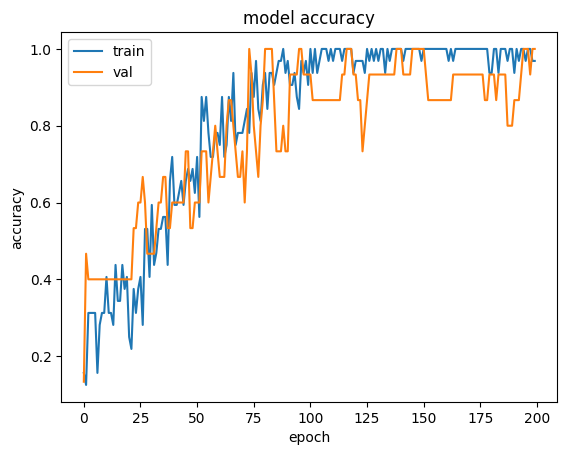

In [25]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

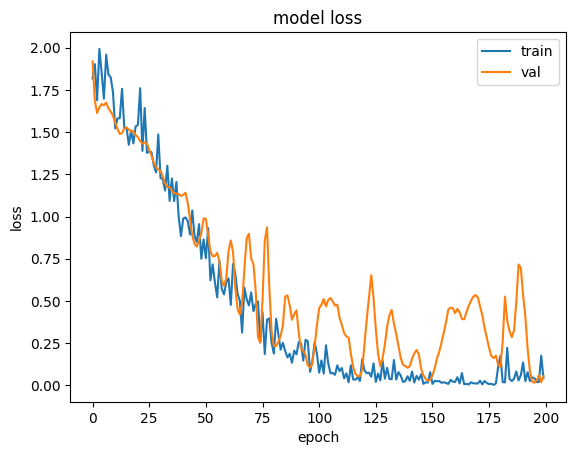

In [26]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')